In [ ]:
# Importación de librerías

import pandas as pd
import numpy as numpy

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1) poner todo en inglés
# 2) añadir interpretaciones en fases 2 y 3

# hoja de ruta:
EXPLORACION:
1) Cargamos los csv
2) Exploración básica (head, tail, sample), echar un vistazo y ver que se carga correctamente. ¿index_col = 0? --> solo si quiero que esa columna sea un indice, para eso es util echar un vistazo al df (en este caso no hace falta index_col = 0)
3) Forma csv y nombre columnas. Entender qué información contiene cada uno. 
4) Info --> tipos de datos, nombres columnas, numero de no nulos.
5) Describe numericos (medidas descriptivas media, mediana, desviacion estandar, max, min...)
6) Describe categoricos --> Recuento, numero categorias, moda y frecuencia absoluta moda. 
7) Nulos?
8) Duplicados?
(en cada fase de la exploración vamos tomando notas de los cambios que creemos que tendremos que hacer en fase de limpieza)
LIMPIEZA:
1) Homogeneizacion nombres columnas
2) Homogeneizacion categorias, decimales en flotantes...
3) Eliminar duplicados
4) Gestionar nulos
5) Unir dataframes

## Fase 1 - Exploración y Limpieza
### 1. Exploración inicial

In [ ]:
df_flight_activity = pd.read_csv("data/customer_flight_activity.csv")

In [ ]:
df_loyalty_history = pd.read_csv("data/customer_loyalty_history.csv")

In [ ]:
def basic_exploration(df):
    display(df.head(2))
    display(df.tail(2))
    display(df.sample(2))
    print(df.info())
    print(f"El dataframe {df} tiene {df.shape[0]} filas y {df.shape[1]} columnas")

In [ ]:
basic_exploration(df_flight_activity)

In [ ]:
basic_exploration(df_loyalty_history)

### 2. Limpieza de datos

- Analisis descriptivo

In [ ]:
df_loyalty_history.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='object')

In [ ]:
df_flight_activity.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='object')

In [ ]:
# preguntar si está bien poner la función así

In [ ]:
descriptive_analysis(df_flight_activity)

NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


No existen datos categóricos para el dataframe


In [ ]:
descriptive_analysis(df_loyalty_history)

NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


CATEGÓRICAS


,count,unique,top,freq
Country,16737,1,Canada,16737
Province,16737,11,Ontario,5404
City,16737,29,Toronto,3351
Postal Code,16737,55,V6E 3D9,911
Gender,16737,2,Female,8410
Education,16737,5,Bachelor,10475
Marital Status,16737,3,Married,9735
Loyalty Card,16737,3,Star,7637
Enrollment Type,16737,2,Standard,15766


- Homogeneización columnas

In [ ]:
def clean_columns(df):
    new_cols = {
        col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_")
        for col in df.columns
    }
    df.rename(columns=new_cols, inplace=True)
    return df

In [ ]:
clean_columns(df_loyalty_history)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


In [ ]:
clean_columns(df_flight_activity)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,12,0,0,0,0,0.0,0,0
405620,999911,2018,12,0,0,0,0,0.0,0,0
405621,999940,2018,12,3,0,3,1233,123.0,0,0
405622,999982,2018,12,0,0,0,0,0.0,0,0


- Eliminación duplicados

In [ ]:
def delete_duplicates(df):
    df = df.drop_duplicates(inplace=True)
    return df

In [ ]:
print(df_flight_activity.duplicated().sum())

1864


In [ ]:
print(df_loyalty_history.duplicated().sum())

0


In [ ]:
delete_duplicates(df_flight_activity)

In [ ]:
delete_duplicates(df_loyalty_history)

In [ ]:
print(df_flight_activity.duplicated().sum())

0


In [ ]:
print(df_loyalty_history.duplicated().sum())

0


In [ ]:
df_loyalty_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loyalty_number      16737 non-null  int64  
 1   country             16737 non-null  object 
 2   province            16737 non-null  object 
 3   city                16737 non-null  object 
 4   postal_code         16737 non-null  object 
 5   gender              16737 non-null  object 
 6   education           16737 non-null  object 
 7   salary              12499 non-null  float64
 8   marital_status      16737 non-null  object 
 9   loyalty_card        16737 non-null  object 
 10  clv                 16737 non-null  float64
 11  enrollment_type     16737 non-null  object 
 12  enrollment_year     16737 non-null  int64  
 13  enrollment_month    16737 non-null  int64  
 14  cancellation_year   2067 non-null   float64
 15  cancellation_month  2067 non-null   float64
dtypes: f

- Cambio de tipos de dato

In [ ]:
def change_months(df):
    months_dict = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
                        5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
                        9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
    
    months_columns = [col for col in df.columns 
                      if "month" in col.lower()]
    
    for col in months_columns:
        df[col] = df[col].replace(months_dict)

In [ ]:
change_months(df_flight_activity)

In [ ]:
df_flight_activity.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,Enero,3,0,3,1521,152.0,0,0
1,100102,2017,Enero,10,4,14,2030,203.0,0,0


In [ ]:
change_months(df_loyalty_history)

In [ ]:
df_loyalty_history.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,Febrero,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,Marzo,NaN,NaN


In [ ]:
df_flight_activity.dtypes

loyalty_number                   int64
year                             int64
month                           object
flights_booked                   int64
flights_with_companions          int64
total_flights                    int64
distance                         int64
points_accumulated             float64
points_redeemed                  int64
dollar_cost_points_redeemed      int64
dtype: object

In [ ]:
df_loyalty_history.dtypes

loyalty_number          int64
country                object
province               object
city                   object
postal_code            object
gender                 object
education              object
salary                float64
marital_status         object
loyalty_card           object
clv                   float64
enrollment_type        object
enrollment_year         int64
enrollment_month       object
cancellation_year     float64
cancellation_month     object
dtype: object

In [ ]:
def convert_to_float(df, columns):
    df[columns] = df[columns].astype(float)
    return df

In [ ]:
convert_to_float(df_flight_activity,["distance", "dollar_cost_points_redeemed"])

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,Enero,3,0,3,1521.0,152.0,0,0.0
1,100102,2017,Enero,10,4,14,2030.0,203.0,0,0.0
2,100140,2017,Enero,6,0,6,1200.0,120.0,0,0.0
3,100214,2017,Enero,0,0,0,0.0,0.0,0,0.0
4,100272,2017,Enero,0,0,0,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,Diciembre,0,0,0,0.0,0.0,0,0.0
405620,999911,2018,Diciembre,0,0,0,0.0,0.0,0,0.0
405621,999940,2018,Diciembre,3,0,3,1233.0,123.0,0,0.0
405622,999982,2018,Diciembre,0,0,0,0.0,0.0,0,0.0


In [ ]:
def convert_to_int(df, columns):
    df[columns] = df[columns].astype("Int64")
    return df

In [ ]:
convert_to_int(df_loyalty_history, "cancellation_year")

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,Febrero,<NA>,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,Marzo,<NA>,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,Julio,2018,Enero
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,Febrero,<NA>,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,Octubre,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,Diciembre,<NA>,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,Septiembre,<NA>,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,Marzo,<NA>,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,Abril,<NA>,NaN


- Tratamiento datos nulos y atípicos

In [ ]:
(df_loyalty_history["salary"] < 0).sum()


np.int64(20)

In [ ]:
def correct_negative_salaries(df, columna):
    df[columna] = df[columna].where(df[columna] >= 0, numpy.nan)
    return df

In [ ]:
df_loyalty_history = correct_negative_salaries(df_loyalty_history, 'salary')

In [ ]:
(df_loyalty_history["salary"] < 0).sum()


np.int64(0)

In [ ]:
print(df_loyalty_history.isnull().sum())
print(df_flight_activity.isnull().sum())

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4258
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64
loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64


In [ ]:
def resumen_nulos(df):
    nulos = (df.isnull().sum() / len(df) * 100).reset_index()
    nulos.columns = ["columna", "%_nulos"]
    return nulos[nulos["%_nulos"] > 0]

In [ ]:
resumen_nulos(df_loyalty_history)

,columna,%_nulos
7,salary,25.440640
14,cancellation_year,87.650117
15,cancellation_month,87.650117


In [ ]:
df_loyalty_history["salary"].value_counts(dropna=False)

salary
NaN         4258
101933.0      23
62283.0       14
51573.0       14
61809.0       14
            ... 
65798.0        1
30767.0        1
46971.0        1
86159.0        1
98892.0        1
Name: count, Length: 5871, dtype: int64

In [ ]:
df_loyalty_history['salary'].isnull().mean() * 100

np.float64(25.44064049710223)

In [ ]:
avg_salary = (df_loyalty_history['salary'].median())

In [ ]:
print(df_loyalty_history['salary'].mean())
print(df_loyalty_history['salary'].median())

79429.57264203862
73510.0


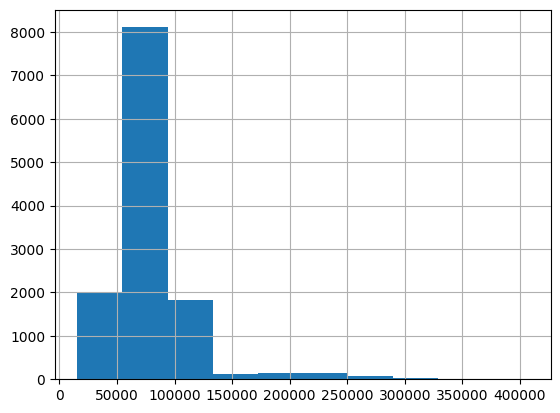

In [ ]:
df_loyalty_history["salary"].hist();

In [ ]:
salary_range = df_loyalty_history["salary"].max() - df_loyalty_history["salary"].min()
salary_variation_coefficient = (df_loyalty_history["salary"].std() / avg_salary) * 100
print(salary_range)
print(salary_variation_coefficient.round(2))

391619.0
47.24


In [ ]:
df_loyalty_history['salary'] = df_loyalty_history['salary'].fillna(df_loyalty_history['salary'].median())

In [ ]:
df_loyalty_history["salary"].value_counts(dropna=False)

salary
73510.0     4260
101933.0      23
61809.0       14
51573.0       14
62283.0       14
            ... 
59220.0        1
31456.0        1
57734.0        1
216901.0       1
73624.0        1
Name: count, Length: 5870, dtype: int64

C:\Users\al101\AppData\Local\Temp\ipykernel_7044\3512195714.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


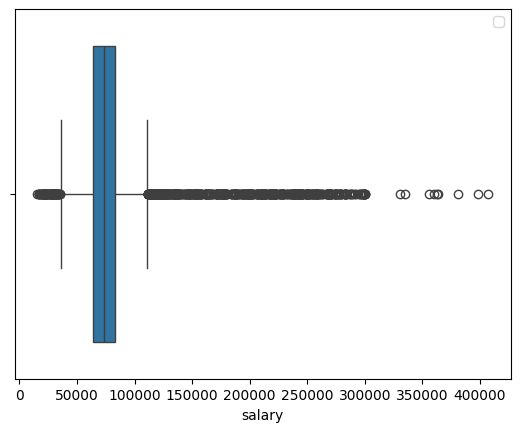

In [ ]:
sns.boxplot(data=df_loyalty_history, x="salary")

plt.legend();

In [ ]:
df_merged = df_flight_activity.merge(df_loyalty_history, how="inner", on="loyalty_number")
df_merged.shape

(403760, 25)

In [ ]:
df_flight_activity.to_csv("data/clean_customer_flight_activity.csv", index=False)
df_loyalty_history.to_csv("data/clean_customer_loyalty_history.csv", index=False)
df_merged.to_csv("data/merged_customer_flight_loyalty.csv", index=False)